In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import networkx as nx
import matplotlib.pyplot as plt
import hypernetx as hnx
from matplotlib.lines import Line2D
import math
import warnings
warnings.filterwarnings("ignore")

from functions import *

In [2]:
data = pd.read_csv('../datasets/simulated_data_4.csv')

In [3]:
data.shape

(100, 15)

In [4]:
data.drop(columns=['A'], axis=1,inplace=True)

In [5]:
data.shape

(100, 14)

### Compute Q-matrix using q function (see functions.py)

In [6]:
q_Matrix = qMatrix(np.array(data))

### Visualize Q-matrix using dendrogram

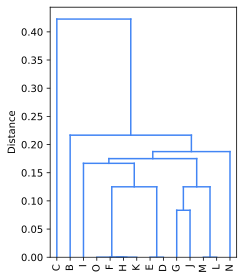

In [7]:
plot_manual_dendrogram(q_Matrix, labels=data.columns)

### Force-directed projection of Q-matrix

B (3.328157137686886, 55.010533544120456)
C (28.531566811129682, 100.0)
D (33.0033469637111, -22.096263605014233)
E (27.509649195328148, -26.20017833228657)
F (9.931241524891426, -39.380015033737095)
G (-31.8624814919668, 12.360518153613059)
H (13.345322460629399, -27.838663197934533)
I (35.12298645724482, -5.269598069022343)
J (-44.02741485061948, -13.585162248847377)
K (18.29089702293924, -41.221456542703265)
L (-52.44346621421303, -29.80055812887792)
M (-55.70437488204506, -23.768203205705976)
N (-3.3738871806404376, 90.00476729375185)
O (18.348457045924096, -28.21572062735606)


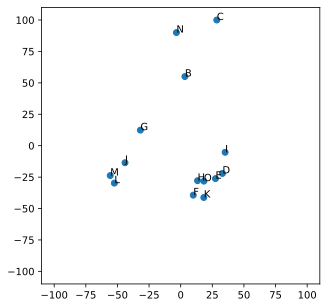

In [8]:
points = projectFeatures(q_Matrix, coolDown=0.6, columns=data.columns, show=True)

In [9]:
projection_df = pd.DataFrame(points, index=data.columns, columns= ['x', 'y'])

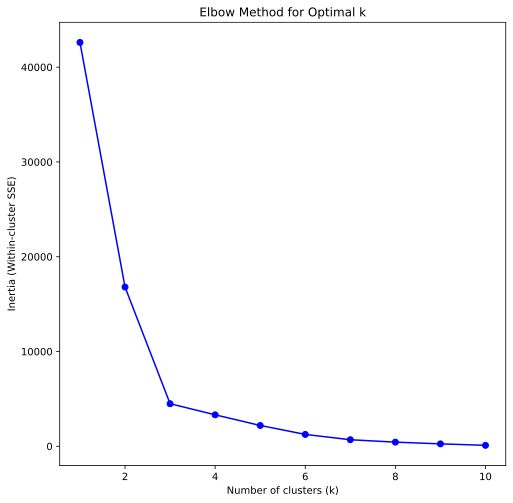

In [10]:
# Elbow method
inertia = []
K = range(1, 11)  # test k from 1 to 10
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(projection_df)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.show()

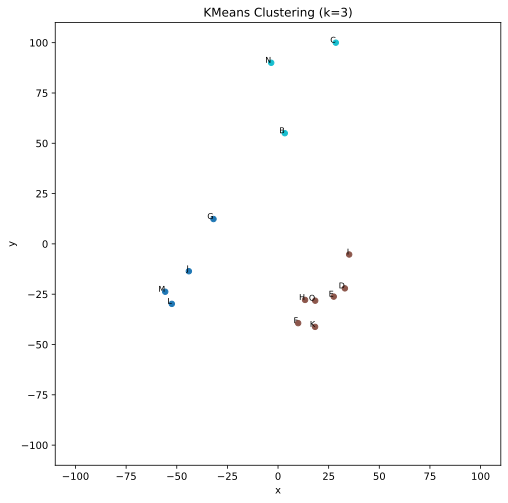

In [11]:
# Choose k based on elbow, then fit final model
optimal_k = 3  # <-- replace with the elbow choice
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
projection_df["cluster"] = kmeans.fit_predict(projection_df)

# Optional: visualize clusters
plt.scatter(projection_df["x"], projection_df["y"], c=projection_df["cluster"], cmap="tab10", s=30)
for label, (x, y) in projection_df[["x", "y"]].iterrows():
    plt.text(x, y, label, fontsize=8, ha='right')
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-110, 110)
plt.ylim(-110, 110)
plt.title(f"KMeans Clustering (k={optimal_k})")
plt.show()


### Visualizing Q-matrix using hypergraph

HYPEREDGES (Dependency groups)
e1: {'G', 'B'}
e2: {'D', 'E', 'O', 'H', 'F', 'K'}
e3: {'H', 'O', 'K', 'F'}
e4: {'D', 'G', 'E', 'M', 'L', 'J', 'N'}
e5: {'O', 'H', 'F', 'K', 'I'}
e6: {'M', 'L', 'J', 'G'}
e7: {'M', 'L'}


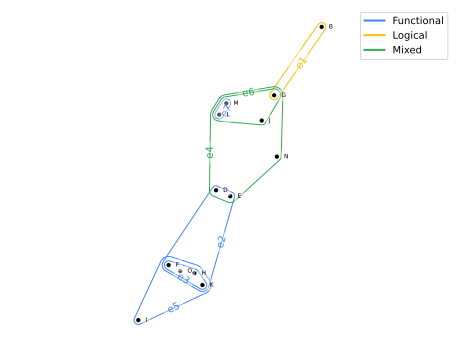

In [12]:
# =============================================================
# 0️⃣ Helper: Wilson confidence interval
# =============================================================
def wilson_interval(k, n, z=1.96):
    """Compute Wilson 95% confidence interval for a proportion (k/n)."""
    if n == 0:
        return (0.0, 1.0)
    p = k / n
    denom = 1 + (z**2 / n)
    center = p + (z**2) / (2 * n)
    half = z * math.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return ((center - half) / denom, (center + half) / denom)


# =============================================================
# 1️⃣ Apply Q-function (asymmetric)
# =============================================================
q_Matrix = qMatrix(np.array(data))   # your Q-function
features = data.columns
Q_df = pd.DataFrame(q_Matrix, index=features, columns=features)
#Q_df = pd.read_csv('qmatrix_metabric_tree-fast.csv', index_col='Unnamed: 0')
#q_Matrix = np.array(Q_df)
#features = data.columns

# =============================================================
# 2️⃣ Build hyperedges using hybrid (threshold + top-k)
# =============================================================
threshold = 0.2
k = 20     # keep strongest k dependencies after thresholding

hyperedges = []

for i, fi in enumerate(features):
    
    # --- step 1: collect candidates that satisfy the threshold ---
    candidates = [
        (features[j], q_Matrix[i, j])
        for j in range(len(features))
        if i != j and q_Matrix[i, j] < threshold
    ]
    
    # If no candidates satisfy the threshold → no hyperedge
    if len(candidates) == 0:
        continue
    
    # --- step 2: sort them by Q-value (smaller = stronger dependency) ---
    candidates_sorted = sorted(candidates, key=lambda x: x[1])
    
    # --- step 3: take top-k strongest dependencies ---
    top_k = [f for (f, qval) in candidates_sorted[:k]]
    
    # --- step 4: build hyperedge ---
    group = set([fi] + top_k)
    
    if len(group) > 1:
        hyperedges.append(group)

# --- remove duplicate hyperedges ---
unique_hyperedges = []
for e in hyperedges:
    if e not in unique_hyperedges:
        unique_hyperedges.append(e)

print("============================================================")
print("HYPEREDGES (Dependency groups)")
print("============================================================")
for idx, e in enumerate(unique_hyperedges, 1):
    print(f"e{idx}: {e}")


# =============================================================
# 3️⃣ Construct incidence matrix
# =============================================================
H = pd.DataFrame(0, index=features, columns=[f"e{i+1}" for i in range(len(unique_hyperedges))])
for i, e in enumerate(unique_hyperedges):
    for f in e:
        H.loc[f, f"e{i+1}"] = 1

#print("\n============================================================")
#print("INCIDENCE MATRIX")
#print("============================================================")
#print(H)

# =============================================================
# 4️⃣ Compute functional/logical ratios + classify using Wilson
# =============================================================
func_thresh = 0        # Q ≤ func_thresh → functional
log_thresh = threshold # func_thresh < Q ≤ log_thresh → logical

#print("\n============================================================")
#print("HYPEREDGE DEPENDENCY SUMMARY (Wilson-based)")
#print("============================================================")

hyperedge_ratios = []

for idx, e in enumerate(unique_hyperedges, 1):
    indices = [features.get_loc(f) for f in e]
    Q_sub = q_Matrix[np.ix_(indices, indices)]
    mask = ~np.eye(len(indices), dtype=bool)
    q_vals = Q_sub[mask]
    n = len(q_vals)

    # Count pairs
    k_func = np.sum(q_vals <= func_thresh)
    k_log  = np.sum((q_vals > func_thresh) & (q_vals <= log_thresh))
    k_none = n - k_func - k_log

    p_func = k_func / n if n else 0
    p_log  = k_log  / n if n else 0

    # Compute Wilson confidence intervals
    Lf, Uf = wilson_interval(k_func, n)
    Ll, Ul = wilson_interval(k_log, n)

    # Classification logic
    if (k_func == 0) and (k_log > 0):
        dep_type = "Logical"        # no functional at all → logical
    elif (k_log == 0) and (k_func > 0):
        dep_type = "Functional"     # no logical at all → functional
    
    elif Lf > Ul:
        dep_type = "Functional"
    elif Ll > Uf:
        dep_type = "Logical"
    else:
        dep_type = "Mixed"

    hyperedge_ratios.append({
        "edge": f"e{idx}",
        "features": e,
        "n_pairs": n,
        "func_ratio": p_func,
        "log_ratio": p_log,
        "func_CI": (Lf, Uf),
        "log_CI": (Ll, Ul),
        "type": dep_type
    })

    #print(f"e{idx}: {dep_type}")
    #print(f"  n_pairs = {n}")
    #print(f"  Functional: {p_func:.3f}  CI = [{Lf:.2f}, {Uf:.2f}]")
    #print(f"  Logical:    {p_log:.3f}  CI = [{Ll:.2f}, {Ul:.2f}]")

# =============================================================
# 5️⃣ Visualize hypergraph (Google color palette + short labels)
# =============================================================

# Build hypergraph structure
H_dict = {col: list(H.index[H[col] == 1]) for col in H.columns}
H_hnx = hnx.Hypergraph(H_dict)

# Short labels (first 3 letters)
short_labels = {f: f[:3] for f in features}

# Google brand colors
google_blue   = "#4285F4"
google_green  = "#34A853"
google_orange = "#FBBC05"
google_gray   = "#9AA0A6"

color_map = {
    "Functional": google_blue,
    "Logical": google_orange,
    "Mixed": google_green
}

edge_colors = [color_map.get(row["type"], google_gray) 
               for _, row in pd.DataFrame(hyperedge_ratios).iterrows()]

# Larger figure
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Draw hypergraph
hnx.draw(
    H_hnx,
    with_node_labels=True,
    with_edge_labels=True,
    edges_kwargs={
        "edgecolors": edge_colors,
        "facecolors": "none",
        "linewidths": 2
    },
    node_radius=0.5,
    ax=ax
)

# Reduce node label font size and replace text manually
for text in ax.texts:
    # Replace full name with short one
    if text.get_text() in short_labels:
        text.set_text(short_labels[text.get_text()])
        text.set_fontsize(6)
    #else:
        #text.set_fontsize(8)  # edge labels (e.g., e1, e2)

# Add legend
legend_elements = [
    Line2D([0], [0], color=google_blue, lw=2, label="Functional"),
    Line2D([0], [0], color=google_orange, lw=2, label="Logical"),
    Line2D([0], [0], color=google_green, lw=2, label="Mixed")
]
plt.legend(handles=legend_elements, loc="best")
#plt.savefig("METABRIC_hypergraph.png", dpi=300, bbox_inches='tight')
plt.show()


# =============================================================
# 6️⃣ Summary Table
# =============================================================
#print("\n============================================================")
#print("SUMMARY TABLE")
#print("============================================================")
#summary_df = pd.DataFrame(hyperedge_ratios)
#summary_df = summary_df[['edge', 'type', 'n_pairs', 'func_ratio', 'log_ratio', 'func_CI', 'log_CI']]
#print(summary_df.to_string(index=False))
